# Installations and Imports

In [3]:
# Install gdown if you don't have it (uncomment the line below if needed)
# !pip install gdown pytorch-msssim scikit-image

import os
import glob
import random
import zipfile
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import gdown

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.cuda.amp import GradScaler, autocast
!pip install pytorch_msssim
import torchvision.transforms.functional as TF
from pytorch_msssim import SSIM as SSIMLoss
from skimage.metrics import peak_signal_noise_ratio as ski_psnr
from skimage.metrics import structural_similarity as ski_ssim

import warnings
warnings.filterwarnings("ignore")

# Download and extract dataset
file_id = '1plYfM-jFJT7TbTMVssuCCFvLzGdxMQ4h'
url = f'https://drive.google.com/uc?id={file_id}'
output = 'dataset.zip'

if not os.path.exists('dataset_content'):
    print("Downloading dataset...")
    gdown.download(url, output, quiet=False)
    print("Extracting...")
    with zipfile.ZipFile(output, 'r') as zip_ref:
        zip_ref.extractall('dataset_content')
    print("Extraction complete.")
else:
    print("Dataset already exists!")

Downloading...
From: https://drive.google.com/uc?id=1plYfM-jFJT7TbTMVssuCCFvLzGdxMQ4h
To: /kaggle/working/dataset.zip
100%|██████████| 21.6M/21.6M [00:00<00:00, 151MB/s]


Extracting...
Extraction complete.


# Configuration and Setup

In [4]:
# Setup device & reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# Global Configurations
DATA_DIR = "/kaggle/working/dataset_content/Dataset" # Change to "./dataset_content/Dataset" if running locally
SAVE_DIR = "./checkpoints"
OUTPUT_DIR = "./outputs"

# Image & scaling
LR_SIZE = 64
HR_SIZE = 128
SCALE = 2
IN_CHANNELS = 1

# Split and Augmentation
TRAIN_RATIO = 0.90
PATCH_SIZE = 48
PATCHES_PER_IMAGE = 32
USE_ROTATION = True
USE_FLIP = True
USE_NOISE = True
NOISE_STD = 0.005

# Model architecture & Training
N_RESBLOCKS = 16
N_FEATS = 64
RES_SCALE = 0.1
EPOCHS = 150
BATCH_SIZE = 16
LR = 1e-4
LR_MIN = 1e-6
WEIGHT_DECAY = 1e-5
CLIP_GRAD = 1.0
LAMBDA_SSIM = 0.1
EARLY_STOP = 20
AMP = torch.cuda.is_available()

os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

Using device: cuda


# Data Loading Pipeline

In [5]:
def normalize(img):
    # Clip and min-max scale to [0, 1]
    img = img.astype(np.float32)
    img = np.clip(img, -0.05, 1.05)
    lo, hi = img.min(), img.max()
    if hi - lo < 1e-8:
        return np.zeros_like(img)
    return (img - lo) / (hi - lo)

class LensingDataset(Dataset):
    def __init__(self, lr_paths, hr_paths, mode="train"):
        self.mode = mode
        self.lr_imgs = [normalize(np.load(p)) for p in lr_paths]
        self.hr_imgs = [normalize(np.load(p)) for p in hr_paths]
        
        self.length = len(lr_paths) * PATCHES_PER_IMAGE if mode == "train" else len(lr_paths)

    def __len__(self):
        return self.length

    def _random_crop(self, lr, hr):
        h, w = lr.shape[-2], lr.shape[-1]
        max_y, max_x = h - PATCH_SIZE, w - PATCH_SIZE
        if max_y <= 0 or max_x <= 0:
            return lr, hr
        y = random.randint(0, max_y)
        x = random.randint(0, max_x)
        return (lr[:, y:y+PATCH_SIZE, x:x+PATCH_SIZE],
                hr[:, y*SCALE:(y+PATCH_SIZE)*SCALE, x*SCALE:(x+PATCH_SIZE)*SCALE])

    def _augment(self, lr, hr):
        if USE_ROTATION and random.random() > 0.25:
            k = random.choice([1, 2, 3])
            lr = torch.rot90(lr, k, dims=[-2, -1])
            hr = torch.rot90(hr, k, dims=[-2, -1])
        if USE_FLIP and random.random() > 0.5:
            lr = torch.flip(lr, dims=[-1])
            hr = torch.flip(hr, dims=[-1])
        if USE_FLIP and random.random() > 0.5:
            lr = torch.flip(lr, dims=[-2])
            hr = torch.flip(hr, dims=[-2])
        if USE_NOISE and random.random() > 0.5:
            lr = torch.clamp(lr + torch.randn_like(lr) * NOISE_STD, 0., 1.)
        return lr, hr

    def __getitem__(self, idx):
        if self.mode == "train":
            img_idx = idx % len(self.lr_imgs)
            lr_t = torch.from_numpy(self.lr_imgs[img_idx])
            hr_t = torch.from_numpy(self.hr_imgs[img_idx])
            lr_t, hr_t = self._random_crop(lr_t, hr_t)
            lr_t, hr_t = self._augment(lr_t, hr_t)
        else:
            lr_t = torch.from_numpy(self.lr_imgs[idx])
            hr_t = torch.from_numpy(self.hr_imgs[idx])
        return lr_t, hr_t

def get_dataloaders():
    lr_paths = sorted(glob.glob(os.path.join(DATA_DIR, "LR", "LR_*.npy")), 
                      key=lambda p: int(Path(p).stem.split("_")[1]))
    hr_paths = sorted(glob.glob(os.path.join(DATA_DIR, "HR", "HR_*.npy")), 
                      key=lambda p: int(Path(p).stem.split("_")[1]))
    
    n = len(lr_paths)
    indices = list(range(n))
    random.shuffle(indices)
    
    n_train = int(n * TRAIN_RATIO)
    train_idx, test_idx = indices[:n_train], indices[n_train:]

    train_ds = LensingDataset([lr_paths[i] for i in train_idx], [hr_paths[i] for i in train_idx], mode="train")
    test_ds = LensingDataset([lr_paths[i] for i in test_idx], [hr_paths[i] for i in test_idx], mode="test")

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True, drop_last=True)
    test_loader = DataLoader(test_ds, batch_size=1, shuffle=False, pin_memory=True)

    return train_loader, test_loader

train_loader, test_loader = get_dataloaders()
print(f"Train batches: {len(train_loader)} | Test samples: {len(test_loader)}")

Train batches: 540 | Test samples: 30


 # EDSR Model and Loss

In [6]:
class ResBlock(nn.Module):
    def __init__(self, n_feats, res_scale=0.1):
        super().__init__()
        self.body = nn.Sequential(
            nn.Conv2d(n_feats, n_feats, 3, 1, 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(n_feats, n_feats, 3, 1, 1)
        )
        self.res_scale = res_scale

    def forward(self, x):
        return x + self.body(x) * self.res_scale

class Upsampler(nn.Sequential):
    def __init__(self, scale, n_feats):
        layers = []
        for _ in range(int(np.log2(scale))):
            layers.extend([nn.Conv2d(n_feats, 4 * n_feats, 3, 1, 1), nn.PixelShuffle(2)])
        super().__init__(*layers)

class EDSR(nn.Module):
    def __init__(self):
        super().__init__()
        self.head = nn.Conv2d(IN_CHANNELS, N_FEATS, 3, 1, 1)
        self.body = nn.Sequential(*[ResBlock(N_FEATS, RES_SCALE) for _ in range(N_RESBLOCKS)])
        self.body_tail = nn.Conv2d(N_FEATS, N_FEATS, 3, 1, 1)
        self.upsample = Upsampler(SCALE, N_FEATS)
        self.tail = nn.Conv2d(N_FEATS, IN_CHANNELS, 3, 1, 1)

    def forward(self, x):
        feat = self.head(x)
        res = self.body_tail(self.body(feat))
        return self.tail(self.upsample(feat + res))

class CombinedLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.l1 = nn.L1Loss()
        self.ssim = SSIMLoss(data_range=1.0, size_average=True, channel=1)

    def forward(self, pred, target):
        l1_loss = self.l1(pred, target)
        ssim_loss = 1.0 - self.ssim(torch.clamp(pred, 0., 1.), torch.clamp(target, 0., 1.))
        return l1_loss + LAMBDA_SSIM * ssim_loss

# Training and Evaluation Functions

In [8]:
def compute_metrics(pred, hr):
    pred, hr = np.clip(pred, 0., 1.), np.clip(hr, 0., 1.)
    return {
        "mse": float(np.mean((pred - hr) ** 2)),
        "psnr": float(ski_psnr(hr, pred, data_range=1.0)),
        "ssim": float(ski_ssim(hr, pred, data_range=1.0))
    }

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    metrics = {"mse": [], "psnr": [], "ssim": []}
    
    for lr, hr in loader:
        lr, hr = lr.to(DEVICE), hr.to(DEVICE)
        sr = torch.clamp(model(lr), 0., 1.)
        m = compute_metrics(sr.squeeze().cpu().numpy(), hr.squeeze().cpu().numpy())
        metrics["mse"].append(m["mse"])
        metrics["psnr"].append(m["psnr"])
        metrics["ssim"].append(m["ssim"])

    return {k: float(np.mean(v)) for k, v in metrics.items()}

def train():
    model = EDSR().to(DEVICE)
    criterion = CombinedLoss().to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=LR_MIN)
    scaler = GradScaler(enabled=AMP)

    history = {"train_loss": [], "test_mse": [], "test_psnr": [], "test_ssim": []}
    best_ckpt = os.path.join(SAVE_DIR, "best_model.pth")
    
    best_psnr = -float('inf')
    patience_counter = 0

    print(f"Starting training on {DEVICE} for {EPOCHS} epochs...")

    for epoch in range(1, EPOCHS + 1):
        model.train()
        epoch_loss = 0.0
        
        for lr, hr in train_loader:
            lr, hr = lr.to(DEVICE), hr.to(DEVICE)
            optimizer.zero_grad()
            
            with autocast(enabled=AMP):
                sr = model(lr)
                loss = criterion(sr, hr)
                
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), CLIP_GRAD)
            scaler.step(optimizer)
            scaler.update()
            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(train_loader)
        scheduler.step()

        test_m = evaluate(model, test_loader)
        
        history["train_loss"].append(avg_loss)
        history["test_mse"].append(test_m["mse"])
        history["test_psnr"].append(test_m["psnr"])
        history["test_ssim"].append(test_m["ssim"])

        is_best = test_m["psnr"] > best_psnr
        if is_best:
            best_psnr = test_m["psnr"]
            patience_counter = 0
            torch.save({"model_state": model.state_dict()}, best_ckpt)
        else:
            patience_counter += 1

        print(f"Epoch {epoch}/{EPOCHS} | Loss: {avg_loss:.4f} | PSNR: {test_m['psnr']:.2f} | SSIM: {test_m['ssim']:.4f} " + ("(Best)" if is_best else ""))

        if patience_counter >= EARLY_STOP:
            print(f"Early stopping triggered after {epoch} epochs.")
            break

    torch.save({"model_state": model.state_dict()}, os.path.join(SAVE_DIR, "final_model.pth"))
    return model, history

# run Tranning

In [9]:
model, history = train()

Starting training on cuda for 150 epochs...
Epoch 1/150 | Loss: 0.0401 | PSNR: 33.98 | SSIM: 0.8632 (Best)
Epoch 2/150 | Loss: 0.0341 | PSNR: 34.40 | SSIM: 0.8512 (Best)
Epoch 3/150 | Loss: 0.0338 | PSNR: 34.64 | SSIM: 0.8671 (Best)
Epoch 4/150 | Loss: 0.0325 | PSNR: 34.40 | SSIM: 0.8768 
Epoch 5/150 | Loss: 0.0323 | PSNR: 34.59 | SSIM: 0.8787 
Epoch 6/150 | Loss: 0.0324 | PSNR: 34.21 | SSIM: 0.8738 
Epoch 7/150 | Loss: 0.0321 | PSNR: 34.84 | SSIM: 0.8778 (Best)
Epoch 8/150 | Loss: 0.0317 | PSNR: 34.79 | SSIM: 0.8706 
Epoch 9/150 | Loss: 0.0314 | PSNR: 34.39 | SSIM: 0.8703 
Epoch 10/150 | Loss: 0.0313 | PSNR: 34.71 | SSIM: 0.8498 
Epoch 11/150 | Loss: 0.0313 | PSNR: 35.10 | SSIM: 0.8804 (Best)
Epoch 12/150 | Loss: 0.0313 | PSNR: 35.13 | SSIM: 0.8792 (Best)
Epoch 13/150 | Loss: 0.0309 | PSNR: 35.04 | SSIM: 0.8729 
Epoch 14/150 | Loss: 0.0309 | PSNR: 34.09 | SSIM: 0.8405 
Epoch 15/150 | Loss: 0.0309 | PSNR: 35.17 | SSIM: 0.8806 (Best)
Epoch 16/150 | Loss: 0.0308 | PSNR: 34.89 | SSIM: 0.8

# Evaluate Baseline & Final Model

In [14]:
@torch.no_grad()
def bicubic_baseline(test_loader):
    metrics = []
    for lr, hr in test_loader:
        lr_up = F.interpolate(lr, scale_factor=SCALE, mode="bicubic", align_corners=False)
        lr_up = torch.clamp(lr_up, 0., 1.)
        for i in range(lr_up.shape[0]):
            metrics.append(compute_metrics(lr_up[i, 0].numpy(), hr[i, 0].numpy()))
            
    avg_mse = np.mean([m['mse'] for m in metrics])
    avg_psnr = np.mean([m['psnr'] for m in metrics])
    avg_ssim = np.mean([m['ssim'] for m in metrics])
    print(f"[Bicubic Baseline] MSE: {avg_mse:.6f} | PSNR: {avg_psnr:.2f} | SSIM: {avg_ssim:.4f}")

# Run Baseline
bicubic_baseline(test_loader)

# Run Best Model Evaluation
best_ckpt = torch.load(os.path.join(SAVE_DIR, "best_model.pth"), map_location=DEVICE)
best_model = EDSR().to(DEVICE)
best_model.load_state_dict(best_ckpt["model_state"])

final_metrics = evaluate(best_model, test_loader)
print("\n--- Final Test Set Evaluation ---")
print(f"MSE: {final_metrics['mse']:.6f} | PSNR: {final_metrics['psnr']:.4f} | SSIM: {final_metrics['ssim']:.4f}")

[Bicubic Baseline] MSE: 0.005888 | PSNR: 23.58 | SSIM: 0.3724

--- Final Test Set Evaluation ---
MSE: 0.000683 | PSNR: 35.6530 | SSIM: 0.8853


# Plot Training History

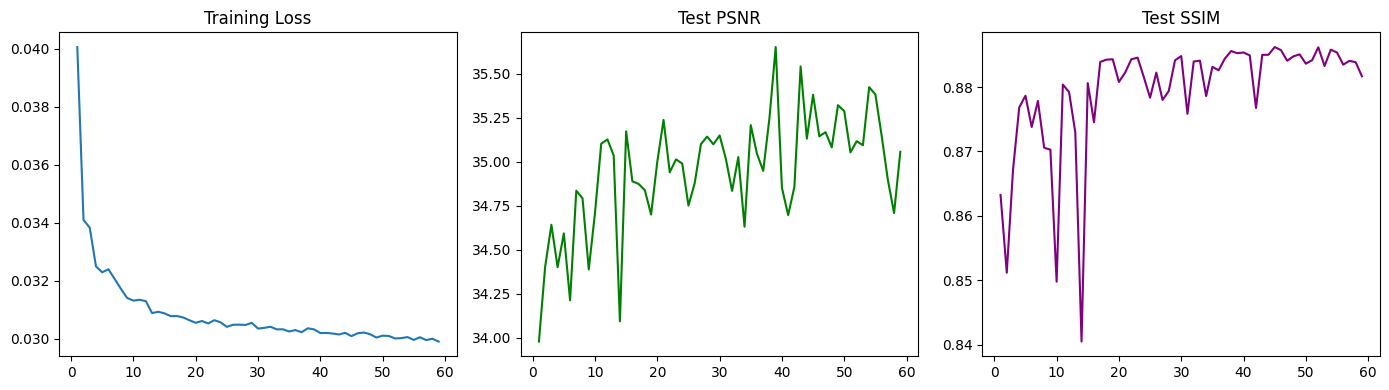

In [30]:
epochs = range(1, len(history["train_loss"]) + 1)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(epochs, history["train_loss"])
axes[0].set_title("Training Loss")

axes[1].plot(epochs, history["test_psnr"], color="green")
axes[1].set_title("Test PSNR")

axes[2].plot(epochs, history["test_ssim"], color="purple")
axes[2].set_title("Test SSIM")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "Tranning_Historys.png"), dpi=150, bbox_inches="tight")
plt.show()

# The Final Visualization Cell

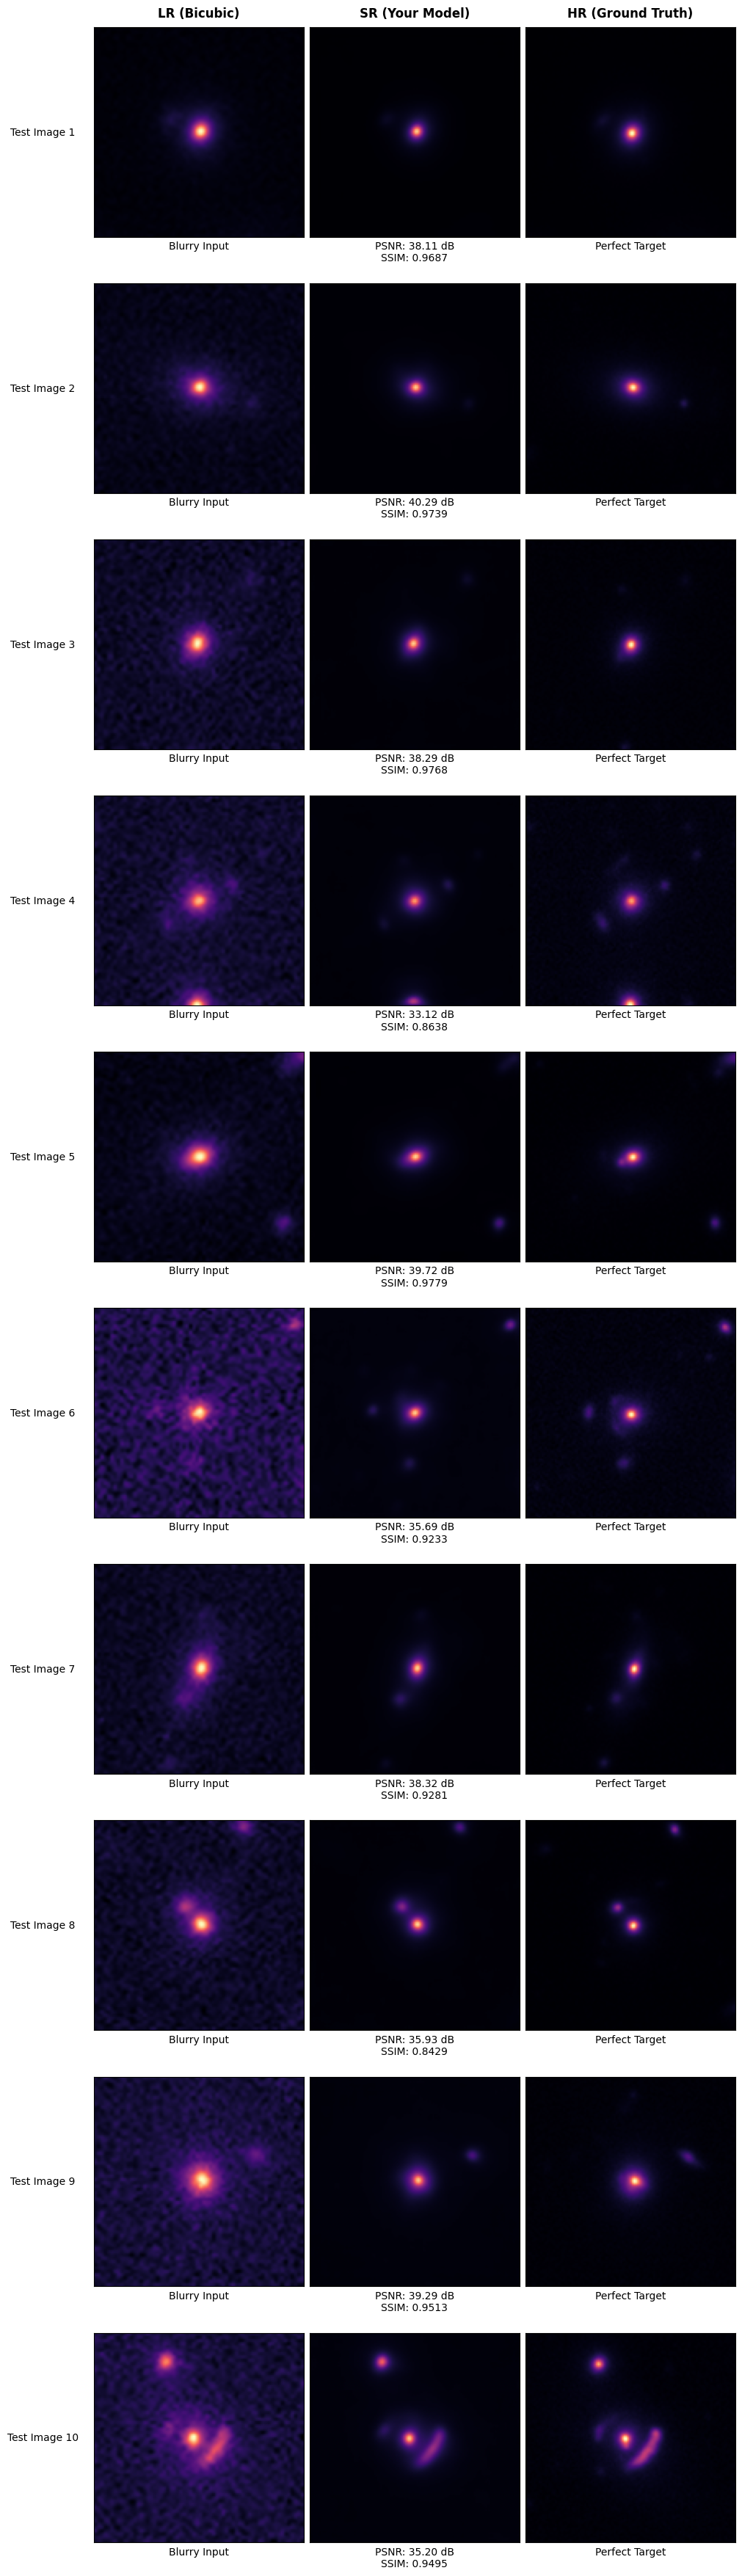

In [31]:
# --- Cell 9: Visualize the Results ---
def visualize_results(model, test_loader, n_samples):
    model.eval()
    samples = []
    
    # Grab a few samples from the test set
    with torch.no_grad():
        for lr, hr in test_loader:
            lr, hr = lr.to(DEVICE), hr.to(DEVICE)
            sr = torch.clamp(model(lr), 0., 1.)
            samples.append((
                lr.squeeze().cpu().numpy(),
                sr.squeeze().cpu().numpy(),
                hr.squeeze().cpu().numpy()
            ))
            if len(samples) >= n_samples:
                break

    # Setup the plot
    fig, axes = plt.subplots(n_samples, 3, figsize=(10, 3.5 * n_samples), constrained_layout=True)
    if n_samples == 1: 
        axes = axes[np.newaxis, :]

    for j, lbl in enumerate(["LR (Bicubic)", "SR (Your Model)", "HR (Ground Truth)"]):
        axes[0, j].set_title(lbl, fontsize=12, fontweight="bold", pad=10)

    # Plot each image
    for i, (lr_np, sr_np, hr_np) in enumerate(samples):
        m = compute_metrics(sr_np, hr_np)
        
        # Upscale LR to HR size just so it looks the same size on the screen
        lr_bic = np.clip(TF.resize(
            torch.from_numpy(lr_np).unsqueeze(0),
            [HR_SIZE, HR_SIZE],
            interpolation=TF.InterpolationMode.BICUBIC
        ).squeeze().numpy(), 0., 1.)

        for j, (img, xlabel) in enumerate([
            (lr_bic, "Blurry Input"),
            (sr_np,  f"PSNR: {m['psnr']:.2f} dB\nSSIM: {m['ssim']:.4f}"),
            (hr_np,  "Perfect Target")
        ]):
            axes[i, j].imshow(img, cmap="magma", vmin=0, vmax=1)
            axes[i, j].set_xlabel(xlabel, fontsize=10)
            axes[i, j].set_xticks([])
            axes[i, j].set_yticks([])

        axes[i, 0].set_ylabel(f"Test Image {i+1}", fontsize=10, rotation=0, labelpad=50, va="center")

    plt.savefig(os.path.join(OUTPUT_DIR, "final_visualizations.png"), dpi=150, bbox_inches="tight")
    plt.show()

# Run the visualization on the best saved model
visualize_results(best_model, test_loader, n_samples=10)

In [28]:
print(os.listdir('checkpoints'))

['final_model.pth', 'best_model.pth']


In [25]:
from IPython.display import FileLink

FileLink('checkpoints/final_model.pth')

/kaggle/working/checkpoints/final_model.pth

In [26]:
from IPython.display import FileLink

FileLink('checkpoints/best_model.pth')

/kaggle/working/checkpoints/best_model.pth